[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A5_people_analytics.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's fifth appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `statsmodels`, `scikit-learn`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A5 (IA) — People Analytics: Attrition, Survival & Pay Equity

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

NB 23 turned churn probabilities into a retention budget — for **customers**. Sooner or later a CHRO walks over with the obvious follow-up: *"can you do that for our employees?"* The stage is the corporate parent behind NB 25's B2B webshop and NB 23's HelpDeskAI — call it **Nordwerk Group** — with roughly 1,400 people across four functions: warehouse & logistics, customer support, sales, and engineering/IT. HR's standing slide says attrition runs at **14 % a year** and that replacing a leaver costs **six to nine months of salary**, depending on the role. Three questions have landed on your desk at once: **who is at risk** (and what, if anything, we should do about it), **what attrition actually costs** (and which function's budget should carry the retention program), and — tabled by the **works council** ahead of the salary round — **is there a gender pay gap, and how large is it really?**

The honest answer to the CHRO is *"yes, but not by copy-paste"*, and the three reasons shape every section of this notebook. First, you don't observe "churned / didn't churn" — you observe **time to leaving, heavily censored**: most employees haven't left *yet*, and treating "still here" as "won't leave" is this module's newest and sneakiest failure mode (§2 plants it and takes it apart). Second, **n is ~1,400, not 20,000** — events per subgroup are rare, so every subgroup claim needs its uncertainty attached (NB 10 habits, not Module 5 point estimates). Third, some of the most *predictive* features are ones you must **not act on** — protected attributes and their proxies — so prediction and permissible action diverge here more than anywhere else in the module.

> 🧠 **Mental model.** Attrition data is a photograph of a race still being run. Some runners have finished — leavers, whose time you know exactly. Most are mid-race — you know only that their time is *longer than* what the photo shows. Every honest number in this notebook comes from treating "still running" as **information about a minimum**, never as a finishing time — and every dishonest number in §2 comes from forgetting that.

## 🎯 Learning objectives

By the end you can:

1. Explain **censoring**, demonstrate the three artifacts it plants in naive leaver-vs-stayer snapshots, and build a **Kaplan–Meier survival curve by hand** — risk sets, event table, $S(t)$ — with nothing but `numpy` and `pandas`.
2. Turn a survival curve into a **euro forecast**: expected leavers per function over the next 12 months × role-specific replacement cost — and show why the function with the *highest attrition rate* is not the one that *costs the most*.
3. Build an honest **"leaves within 12 months"** model via time-aware cohort snapshots and a temporal split, and beat the *"flag everyone in their first year"* heuristic where it counts: in euros, not AUC.
4. Derive the **break-even leave probability** $p^* = C / (s \cdot R)$ from package cost, save rate and replacement cost, and produce a budget-constrained, economics-ranked intervention list — plus the ethics guardrails that must ride along with it.
5. Measure a pay gap **twice** — raw and adjusted — decompose the difference into composition vs within-job, and say precisely what each number does and does not mean (including the mediator trap that lets you "adjust away" discrimination).
6. Name the governance constraints real people analytics lives under: k-anonymity, GDPR Art. 22, works-council codetermination, survey honesty, and self-fulfilling predictions.

## ✅ Prerequisites

**NB 23** (this notebook transplants its expected-value targeting rule into HR), **NB 18** (honest evaluation, temporal discipline), **NB 10** (confidence intervals — small-n HR data leans on them constantly). **A4**'s confounder/mediator language returns in §5, and its sleeping dogs reappear wearing lanyards in the stretch exercises. **A1** supplies the `statsmodels` OLS workflow. All data is generated inline; everything runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

MONTHS = 96                      # Jan 2018 .. Dec 2025 -- eight years of HR history
PKG_COST = 3_000.0               # retention package: stay bonus + development budget, EUR
SAVE_RATE = 0.25                 # assumed share of true leavers a package keeps -- ASSUMED, not measured (SS4)
REPL_MONTHS = {"Warehouse": 6, "Support": 6, "Sales": 8, "Engineering": 9}   # months of salary to replace a leaver

print("CHRO's replacement-cost table (months of salary):",
      ", ".join(f"{f} {m}" for f, m in REPL_MONTHS.items()))
print(f"A retention package costs EUR {PKG_COST:,.0f} and is assumed to save {SAVE_RATE:.0%} of true leavers.")

CHRO's replacement-cost table (months of salary): Warehouse 6, Support 6, Sales 8, Engineering 9
A retention package costs EUR 3,000 and is assumed to save 25% of true leavers.


## 1. The business: one HR extract, three questions

HR hands you a single extract: **every person hired since January 2018**, one row each. Leavers carry an exit date; everyone else was still employed on 31 Dec 2025 — the snapshot date. Per person you get:

- `function` (Warehouse, Support, Sales, Engineering) and `level` (1–5, the pay grade),
- `salary` (annual, EUR, full-time equivalent) and `pay_ratio` — salary relative to the **band midpoint** for that function × level × tenure (1.00 = paid to band),
- `female` (the works-council question needs it; §4's model must not), `age_hire`,
- `overtime` (h/month), `engagement` (latest annual survey, 1–5), `perf` (last rating), `commute` (km), `span` (how many people their *manager* juggles), `stalled` (no promotion on record),
- `hire_m`, `tenure_m` (months observed), `left`, `exit_m` — plus `last_survey` and `repl_cost`, which get their moments later.

Because we *simulate* Nordwerk's workforce, we get the same superpower A4 enjoyed: the generator returns each person's **true monthly leaving hazard** (god mode). We will use it only to check our estimates — every business number is computed from the extract alone, exactly as you would in production.

What the generator plants (and the notebook must recover): attrition driven by **low tenure** (a hard first-year spike), **overtime**, **low engagement**, **below-band pay** and a **stalled career** (no promotion once tenure passes three years); warehouse turning over fastest and engineering slowest; and a gender pay gap that is **partly composition** (who holds which function and level — including a planted tilt in level assignment) and **partly a −2.5 % within-level residual**. Keep that last sentence; §5 lives on it.

In [2]:
FUNCS = ["Warehouse", "Support", "Sales", "Engineering"]
SHARE = [0.41, 0.24, 0.14, 0.21]                       # hiring mix 2018-2025
BASE_SALARY = {"Warehouse": 25_000, "Support": 27_000, "Sales": 37_000, "Engineering": 50_000}
FEMALE_P = {"Warehouse": 0.34, "Support": 0.60, "Sales": 0.47, "Engineering": 0.23}
BASE_HAZ = {"Warehouse": 0.0205, "Support": 0.0136, "Sales": 0.0122, "Engineering": 0.0092}
FUNC_LEVEL = {"Warehouse": 1.55, "Support": 1.95, "Sales": 2.35, "Engineering": 2.65}
OT_MEAN = {"Warehouse": 12.0, "Support": 9.0, "Sales": 8.0, "Engineering": 7.0}
GAP_PLANTED = 0.025                                    # within-level pay penalty for women -- SS5 must find it


def build_workforce(n_hired=2550, seed=7):
    """Eight years of hires, each with a TRUE monthly leaving hazard.

    Returns (df, hazard_matrix). The matrix is god mode: row i, column t is
    P(employee i leaves in tenure month t+1 | still there). Business numbers
    must come from df alone; the matrix is for checking only.
    """
    rng = np.random.default_rng(seed)
    func = rng.choice(FUNCS, n_hired, p=SHARE)
    w = 1.0 + np.arange(MONTHS) / 60.0                 # the group grew, so hiring did too
    hire_m = rng.choice(np.arange(MONTHS), n_hired, p=w / w.sum())

    female = rng.random(n_hired) < np.array([FEMALE_P[f] for f in func])
    age_hire = np.clip(rng.gamma(6.5, 4.2, n_hired) + 19, 19, 60).round(0)
    commute = np.clip(rng.gamma(2.0, 11, n_hired), 1, 90).round(0)          # km
    span = rng.integers(3, 16, n_hired)                # their manager's team size
    overtime = rng.gamma(2.0, np.array([OT_MEAN[f] for f in func]) / 2.0).round(1)
    perf = np.clip(rng.normal(3.2, 0.7, n_hired), 1, 5).round(1)
    engagement = np.clip(3.3 - 0.045 * (overtime - 9) + rng.normal(0, 0.75, n_hired), 1, 5).round(1)
    stalled = rng.random(n_hired) < 0.38               # the never-promoted
    pay_ratio = np.exp(0.030 * (perf - 3.2) - GAP_PLANTED * female + rng.normal(0, 0.05, n_hired))

    # ---- the true monthly hazard: base rate x first-year spike x personal risk ----
    t = np.arange(MONTHS)
    shape_t = 0.55 + 1.90 * np.exp(-t / 11.0)          # the first-year spike
    lin = (0.070 * (overtime - 9) - 0.85 * (engagement - 3.2)
           - 0.9 * (pay_ratio - 1) + 0.014 * (commute - 20) + 0.030 * (span - 9))
    h = np.array([BASE_HAZ[f] for f in func])[:, None] * shape_t[None, :] * np.exp(lin)[:, None]
    h = h * np.exp(0.65 * (stalled[:, None] & (t[None, :] >= 36)))   # stalled careers sour after year 3
    h = h.clip(0, 0.5)

    # ---- one uniform draw per person turns the hazard into a leaving time ----
    surv = np.cumprod(1 - h, axis=1)
    u = rng.random(n_hired)
    leaves = surv < u[:, None]
    T = np.where(leaves.any(axis=1), leaves.argmax(axis=1) + 1, 10**6)   # true exit month (tenure)
    observable = MONTHS - hire_m                       # how long we get to WATCH this person
    left = T <= observable
    tenure = np.minimum(T, observable)                 # ...otherwise the row is CENSORED at the snapshot

    level = np.clip(np.round(
        np.array([FUNC_LEVEL[f] for f in func]) + 0.35 * (age_hire - 32) / 10
        + 0.010 * tenure - 0.26 * female + rng.normal(0, 0.6, n_hired)), 1, 5).astype(int)
    band_mid = (np.array([BASE_SALARY[f] for f in func]) * 1.13 ** (level - 1)
                * np.exp(0.0012 * tenure))             # the salary-band midpoint
    salary = (band_mid * pay_ratio).round(-2)          # annual, EUR

    df = pd.DataFrame(dict(
        function=func, female=female.astype(int), age_hire=age_hire, level=level,
        hire_m=hire_m, tenure_m=tenure, left=left.astype(int),
        salary=salary, pay_ratio=pay_ratio.round(3), overtime=overtime,
        engagement=engagement, perf=perf, commute=commute, span=span,
        stalled=stalled.astype(int)))
    df["exit_m"] = np.where(df.left == 1, df.hire_m + df.tenure_m, np.nan)
    df["repl_cost"] = df.function.map(REPL_MONTHS) * df.salary / 12      # EUR to replace this person
    rng2 = np.random.default_rng(99)
    df["last_survey"] = np.clip(df.engagement - 1.1 * df.left            # a leaver's final wave is bitter
                                + rng2.normal(0, 0.35, len(df)), 1, 5).round(1)
    return df, h


df, H_TRUE = build_workforce()
df[["function", "female", "level", "salary", "overtime", "engagement", "tenure_m", "left"]].head()

,function,female,level,salary,overtime,engagement,tenure_m,left
0,Support,0,2,32400.0,11.0,2.4,6,1
1,Engineering,0,3,63200.0,4.8,3.2,31,0
2,Sales,1,4,54000.0,3.3,5.0,9,0
3,Warehouse,0,2,30600.0,10.3,2.3,1,1
4,Warehouse,1,3,31000.0,8.6,2.1,3,0


In [3]:
active = df[df.left == 0]
print(f"hired since Jan 2018  : {len(df):,}")
print(f"active on 31 Dec 2025 : {len(active):,}   (left over the eight years: {df.left.sum():,})")
print(f"headcount by function : {active.function.value_counts().to_dict()}")
print(f"women among actives   : {active.female.mean():.1%}")

on_book = df[(df.hire_m <= 84) & (df.exit_m.fillna(np.inf) > 84)]      # employed at the start of 2025
left_12m = int(((on_book.exit_m > 84) & (on_book.exit_m <= 96)).sum())
print(f"\nlast 12 months: {left_12m} of {len(on_book):,} employees left "
      f"-> attrition {left_12m / len(on_book):.1%}   (HR's slide claims 14 %)")

hired since Jan 2018  : 2,550
active on 31 Dec 2025 : 1,344   (left over the eight years: 1,206)
headcount by function : {'Warehouse': 414, 'Engineering': 376, 'Support': 324, 'Sales': 230}
women among actives   : 39.0%

last 12 months: 152 of 1,180 employees left -> attrition 12.9%   (HR's slide claims 14 %)


## 2. The censoring trap — why the snapshot lies

A workforce of 1,344 with 12.9 % walking out per year — close enough to HR's 14 % headline that nobody argues. Now watch what happens when a well-meaning analyst treats the extract like a Module 5 dataset: every row gets a label, `left` vs `stayed`, and the summary statistics write themselves. Three of them end up on the CHRO's desk. All three are wrong, each in a different way — run the cell, then we take them apart.

In [4]:
# --- the analyst's snapshot read: everyone ever hired, labeled leaver/stayer ---
print(f"share of all-time staff flagged 'leaver'   : {df.left.mean():.1%}")
print(f"mean tenure -- leavers : {df.loc[df.left == 1, 'tenure_m'].mean():.1f} months"
      f"   stayers: {df.loc[df.left == 0, 'tenure_m'].mean():.1f} months")
print(f"median completed tenure of leavers          : {df.loc[df.left == 1, 'tenure_m'].median():.0f} months")

by_year = (df.assign(hire_year=2018 + df.hire_m // 12)
             .groupby("hire_year").left.agg(share_left="mean", hired="size"))
print("\n'loyalty by hire cohort' (the analyst's slide):")
print(by_year.round(2).to_string())

share of all-time staff flagged 'leaver'   : 47.3%
mean tenure -- leavers : 13.1 months   stayers: 36.3 months
median completed tenure of leavers          : 6 months

'loyalty by hire cohort' (the analyst's slide):
           share_left  hired
hire_year                   
2018             0.61    198
2019             0.62    219
2020             0.60    289
2021             0.51    334
2022             0.52    330
2023             0.47    358
2024             0.42    361
2025             0.26    461


Three artifacts, one disease:

1. **"47 % of our staff leaves"** — that's eight years of exits divided by eight years of hires, presented as if it were a rate. It has no time unit. It is not attrition; it is arithmetic wearing attrition's clothes.
2. **"Leavers last 13 months, stayers 36 — long-tenured people are safe"** — leavers' clocks *stopped* at exit; stayers' clocks are *still ticking*, and recent hires haven't had time to leave yet. The comparison is between finished races and races in progress. A classifier trained on these labels dutifully learns "high tenure ⇒ stayer" — it has learned the shape of the observation window, not a fact about people.
3. **"Loyalty is collapsing — the 2018 cohort lost 61 %, the 2025 cohort only 26 %"** (or, read the other way, "improving"). Neither. The 2018 cohort has had **eight years** of chances to leave; the 2025 cohort has had one. The gradient is exposure, not culture.

The disease is **censoring**: for 1,344 of 2,550 rows the thing we care about — time to leaving — hasn't finished happening. The cure has been standard since 1958, and it's small enough to build by hand. For each tenure month $t$, define the **risk set** $n_t$ — everyone *observed* for at least $t$ months, whether they eventually left or not — and count $d_t$, those who actually left in month $t$. Then

$$h(t) = \frac{d_t}{n_t} \qquad\qquad S(t) = \prod_{u \le t}\bigl(1 - h(u)\bigr)$$

$h(t)$ is the **hazard** — the share of month-$t$ survivors who don't make it to month $t+1$ — and $S(t)$, the **Kaplan–Meier curve**, chains those monthly survival rates together. The censoring magic is all in the bookkeeping: a still-employed row with 30 months of tenure sits in the risk sets for months 1–30, contributing what we *know* about them ("survived at least this long"), and then simply drops out of the denominator — never counted as an event, never assumed safe. That is the mental model in one line: **censored rows testify about the months we watched them, and stay silent about the rest.**

In [5]:
def km_curve(sub):
    """Kaplan-Meier by hand. Censored rows count in every risk set they
    survived through -- and never as events. That is the whole trick."""
    months = np.arange(1, MONTHS + 1)
    at_risk = (sub.tenure_m.values[None, :] >= months[:, None]).sum(axis=1)
    exits = ((sub.tenure_m.values[None, :] == months[:, None])
             & (sub.left.values[None, :] == 1)).sum(axis=1)
    hazard = np.divide(exits, at_risk, out=np.zeros(MONTHS), where=at_risk > 0)
    return pd.DataFrame(dict(month=months, at_risk=at_risk, exits=exits,
                             hazard=hazard, S=np.cumprod(1 - hazard)))


def km_median(ev):
    """First month where S(t) <= 0.5 -- NaN if the curve never gets there."""
    hit = ev.loc[ev.S <= 0.5, "month"]
    return int(hit.iloc[0]) if len(hit) else np.nan


event = km_curve(df)
print("the event table -- first six risk sets:")
print(event.head(6).round(4).to_string(index=False))
print(f"\nsurvival milestones: S(12) = {event.S[11]:.3f}   S(24) = {event.S[23]:.3f}   S(48) = {event.S[47]:.3f}")

the event table -- first six risk sets:
 month  at_risk  exits  hazard      S
     1     2550    203  0.0796 0.9204
     2     2316    115  0.0497 0.8747
     3     2168    101  0.0466 0.8339
     4     2041     77  0.0377 0.8025
     5     1922     76  0.0395 0.7707
     6     1820     50  0.0275 0.7496

survival milestones: S(12) = 0.658   S(24) = 0.573   S(48) = 0.472


### 🔮 Predict the output

The analyst's slide says leavers last **13 months** on average, and the naive median completed tenure was just **6**. The Kaplan–Meier curve above already shows S(12) = 0.658 — meaning two-thirds of hires survive their first year.

So: what is the **honest median** — the tenure month where $S(t)$ first drops through 0.5, i.e. the point by which half of all hires are actually gone? Commit to a number before running the next cell: still ~13 months? ~24? ~36? More?

KM median tenure, all staff: 41 months
  Warehouse    median  13 months   S(12) = 0.51
  Support      median  50 months   S(12) = 0.72
  Sales        median  70 months   S(12) = 0.75
  Engineering  median  90 months   S(12) = 0.82


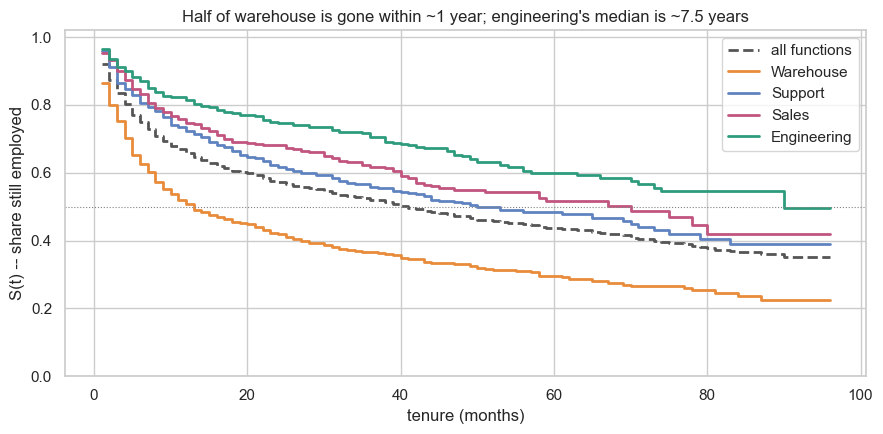

In [6]:
PALETTE = {"Warehouse": "#e88b3a", "Support": "#5f83c0", "Sales": "#c2557f", "Engineering": "#2e9c7c"}

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.step(event.month, event.S, where="post", color="#555555", lw=2, ls="--", label="all functions")
HZ, med_rows = {}, []
for f in FUNCS:
    ev_f = km_curve(df[df.function == f])
    HZ[f] = ev_f.hazard.values                        # per-function hazards -- SS3 reuses these
    ax.step(ev_f.month, ev_f.S, where="post", color=PALETTE[f], lw=2, label=f)
    med_rows.append((f, km_median(ev_f), ev_f.S[11]))
ax.axhline(0.5, color="gray", lw=0.8, ls=":")
ax.set_xlabel("tenure (months)")
ax.set_ylabel("S(t) -- share still employed")
ax.set_ylim(0, 1.02)
ax.set_title("Half of warehouse is gone within ~1 year; engineering's median is ~7.5 years")
ax.legend()
plt.tight_layout()

print(f"KM median tenure, all staff: {km_median(event)} months")
for f, m, s12 in med_rows:
    m_str = ">96" if np.isnan(m) else f"{int(m)}"
    print(f"  {f:<12} median {m_str:>3} months   S(12) = {s12:.2f}")

The honest median is **41 months — three and a half years**, more than triple the "13 months" on the analyst's slide. Both numbers came from the same extract; the difference is that one of them let 1,344 still-running races vote.

The per-function curves carry the operational story. **Warehouse** loses half of a hiring cohort within **13 months** (S(12) = 0.51 — a coin flip that a new picker sees their first anniversary), while **Engineering**'s median is **90 months** and Sales' 70. One honesty note before anyone quotes the right-hand edge of that figure: the curves get *less trustworthy* as $t$ grows, because only the earliest hires can contribute to late risk sets — by month 90 the engineering risk set is down to eleven people, and the step sizes show it. Small $n$ arrives quietly in HR data; it will keep doing so all notebook.

The censoring lesson, restated once because it's the module's newest: the naive numbers weren't *noisy*, they were **biased in a knowable direction** — completed-tenure averages always understate true tenure, because the long stays are precisely the ones still running. When you see "average tenure of leavers" in a deck, you now know both what it measures and what it doesn't.

---

### ✋ Quick exercise (~2 min) — read the risk set

From the printed event table: **1,922** employees were still at risk at the start of month 5, and **76** of them left during it. Compute the month-5 hazard $h(5)$, then chain $S(5) = S(4)\,(1 - h(5))$ using the table's $S(4)$ — and check both against the table's own row. Why is $n_5 = 1{,}922$ *smaller* than $n_4 = 2{,}041$ by **more** than the 77 who left in month 4?

In [7]:
# ✍️ Your turn 👇
# h5 = exits / at_risk in month 5
# S5 = S(4) * (1 - h5)        -- read S(4) from the event table
# then: where did the other missing people go, if only 77 LEFT in month 4?

<details>
<summary>✅ <b>Solution</b></summary>

```python
h5 = 76 / 1922
S4 = event.loc[event.month == 4, "S"].iloc[0]
print(f"h(5) = {h5:.4f}   S(5) = {S4 * (1 - h5):.4f}"
      f"   (table: {event.loc[event.month == 5, 'S'].iloc[0]:.4f})")
print(f"risk set shrank by {2041 - 1922}, but only 77 left -> "
      f"{2041 - 1922 - 77} rows were CENSORED at 4 months of observation")
```

$h(5) = 76/1922 \approx 0.0395$ and the chained $S(5)$ matches the table to four decimals — the curve really is just these two columns multiplied down the page. The extra shrinkage is the point of the exercise: **42 people were hired ~4 months before the snapshot**, so after month 4 we simply stop seeing them. They leave the denominator *without ever being counted as leavers* — censoring handled correctly, in one subtraction you can now explain to an auditor.
</details>

## 3. From survival curves to euros — what attrition actually costs

A survival curve impresses exactly nobody in a budget meeting. The CHRO's two questions are *"what does this cost?"* and *"where?"* — and the honest answer multiplies two quantities we now have:

1. **Expected leavers, next 12 months.** For each *current* employee with tenure $t$, the chance they leave within a year is $p = 1 - \prod_{u=t+1}^{t+12} (1 - h_f(u))$, read off their **function's** estimated hazard curve at their **own** position on it. Summing $p$ over a function's headcount gives its expected exits — properly weighted by where its people sit on the tenure curve, which a flat "14 %" never is.
2. **Replacement cost per leaver.** The CHRO's table from the constants cell: recruiting, agency fees, the vacancy, and the new hire's ramp-up time — **6 months of salary** in warehouse and support, **8** in sales, **9** in engineering, priced at each person's actual salary.

One warning before the table prints. Every retention deck ranks functions by their **rate**, because the rate is the scary-looking number. Watch what happens to the ranking when the euros arrive.

In [8]:
rows = []
for f in FUNCS:
    sub = active[active.function == f]
    start = np.minimum(sub.tenure_m.values, MONTHS - 12)          # clamp the hazard lookup window
    p12 = np.array([1 - np.prod(1 - HZ[f][s:s + 12]) for s in start])
    rows.append(dict(function=f, headcount=len(sub),
                     exp_rate=p12.mean(), exp_leavers=p12.sum(),
                     avg_repl_eur=sub.repl_cost.mean(),
                     eur_at_risk=(p12 * sub.repl_cost.values).sum()))
cost_table = pd.DataFrame(rows).set_index("function")

show = cost_table.copy()
show["exp_rate"] = (show.exp_rate * 100).round(1)
show["exp_leavers"] = show.exp_leavers.round(1)
show[["avg_repl_eur", "eur_at_risk"]] = show[["avg_repl_eur", "eur_at_risk"]].round(-2)
print(show.rename(columns={"exp_rate": "exp_rate_%"}).to_string())

print(f"\nexpected leavers, next 12 months: {cost_table.exp_leavers.sum():.0f}"
      f"   (for reference -- actual leavers, last 12 months: {left_12m})")
print(f"the attrition bill, next 12 months: EUR {cost_table.eur_at_risk.sum():,.0f}")

             headcount  exp_rate_%  exp_leavers  avg_repl_eur  eur_at_risk
function                                                                  
Warehouse          414        16.6         68.7       15200.0    1013100.0
Support            324        10.4         33.8       17400.0     571400.0
Sales              230         9.1         21.0       33500.0     688900.0
Engineering        376         7.8         29.4       52900.0    1543600.0

expected leavers, next 12 months: 153   (for reference -- actual leavers, last 12 months: 152)
the attrition bill, next 12 months: EUR 3,816,877


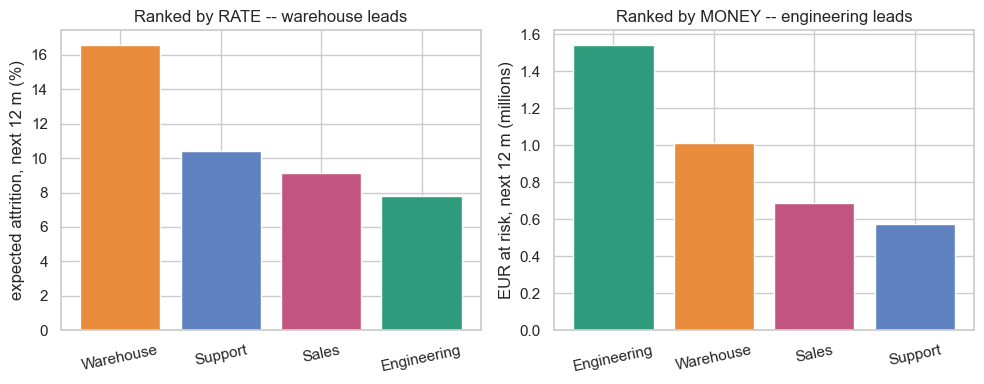

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
by_rate = cost_table.sort_values("exp_rate", ascending=False)
axes[0].bar(by_rate.index, by_rate.exp_rate * 100, color=[PALETTE[f] for f in by_rate.index])
axes[0].set_ylabel("expected attrition, next 12 m (%)")
axes[0].set_title("Ranked by RATE -- warehouse leads")
by_eur = cost_table.sort_values("eur_at_risk", ascending=False)
axes[1].bar(by_eur.index, by_eur.eur_at_risk / 1e6, color=[PALETTE[f] for f in by_eur.index])
axes[1].set_ylabel("EUR at risk, next 12 m (millions)")
axes[1].set_title("Ranked by MONEY -- engineering leads")
for ax in axes:
    ax.tick_params(axis="x", rotation=12)
plt.tight_layout()

First, a credibility check that should become a habit: the survival machinery expects **153** leavers next year, and **152** actually left last year — the model of the process reproduces the process. Now the two panels.

**The ranking flips.** Warehouse tops the rate chart at **16.6 %** — more than double engineering's **7.8 %** — yet engineering tops the money chart at **€1.54 m** against warehouse's **€1.01 m**. The reason is the third column: replacing a warehouse picker costs ~**€15,200** (six months of a €30k salary), replacing an engineer ~**€52,900** (nine months of a €70k one). Twenty-nine expected engineering exits out-cost sixty-nine warehouse ones. Total bill: **€3.82 m a year** — for a group this size, attrition is a middle manager's entire P&L walking out the door annually.

A rate-chaser — and most retention decks are written by rate-chasers — reallocates the budget to warehouse, celebrates a two-point rate drop, and never notices the program was spending €3,000 packages to avoid €15,200 replacements *that mostly weren't preventable at that price anyway* (§4 makes this precise). The rate is a **denominator choice**; the euro column is the business. This is NB 24's lesson — the metric that sounds like the mission is not the mission — wearing an HR badge.

---

### ✋ Quick exercise (~2 min) — the rate-chaser's mistake, quantified

Using `cost_table`: rank the four functions by `exp_rate` and by `eur_at_risk`, and compute how many euros of next-year attrition risk ride on **one percentage point** of attrition rate in each function (`eur_at_risk / (exp_rate * 100)`). How much more is an engineering point worth than a warehouse point?

In [10]:
# ✍️ Your turn 👇
# ranks = cost_table[["exp_rate", "eur_at_risk"]].rank(ascending=False)
# eur_per_point = cost_table.eur_at_risk / (cost_table.exp_rate * 100)

<details>
<summary>✅ <b>Solution</b></summary>

```python
cp2 = cost_table[["exp_rate", "eur_at_risk"]].copy()
cp2["rank_rate"] = cp2.exp_rate.rank(ascending=False).astype(int)
cp2["rank_eur"] = cp2.eur_at_risk.rank(ascending=False).astype(int)
cp2["eur_per_point"] = (cp2.eur_at_risk / (cp2.exp_rate * 100)).round(-2)
print(cp2.round(3).to_string())
ratio = cp2.eur_per_point["Engineering"] / cp2.eur_per_point["Warehouse"]
print(f"\none engineering point of attrition costs {ratio:.1f}x a warehouse point")
```

Warehouse is rank 1 by rate and rank 2 by euros; engineering is rank 4 by rate and rank 1 by euros. A percentage point of engineering attrition carries ~**€197k** of replacement risk against ~**€61k** in warehouse — roughly **3.2×**. Neither ranking is *wrong*; they answer different questions ("where is the churn?" vs "where is the money?"), and only one of them should size a budget.
</details>

## 4. Who is at risk — and who is worth €3,000

Now the CHRO's first question: *who* is at risk, so HR can act before the resignation letter. That is a prediction problem — but §2 showed that the obvious training set (leaver/stayer labels on the whole extract) is poisoned by censoring. The classification-compatible fix is a **time-aware cohort**:

> Pick a snapshot date $c$ far enough in the past that the future you want to predict **has already happened**. Take everyone employed at $c$, build features **as of $c$**, and label them with "left within the 12 months after $c$" — a label that is *fully observed* for every row, leaver and stayer alike, because the window closed before the data ends.

We take **two training snapshots** — January 2023 and January 2024 (months 60 and 72) — and stack them; the same person can appear in both, at different tenures, which is the standard *person-period* construction and roughly doubles our precious event count. Validation is the **January 2025** snapshot (month 84), whose label window runs to the end of the data. The split respects time exactly as NB 26 demanded: every training label is settled before the first validation label begins, so nothing about 2025's exits can leak backwards.

Features as of the snapshot: tenure, overtime, engagement, pay-vs-band, commute, manager's span, stalled-career flag, level and function. (In this simulation the traits are stable; in production each would be snapshotted *as of $c$* from its own history — the 🧪 Debug-me shows exactly what happens to whoever skips that step.) Two columns are deliberately **absent**: `female` and `age_hire`. Both would add AUC; neither is a lawful or decent input to a list of people who get *treated differently* as a result. Hold that thought — the guardrail paragraph after the money table finishes it.

Two models compete — NB 17's logistic regression and the gradient boosting that outgunned it on 20,000 customers — plus the baseline every HR veteran will offer for free: **"flag everyone in their first year."** After §2, that heuristic should worry you precisely because it is *not stupid*: the first-year spike is real.

In [11]:
def cohort(c):
    """Everyone on the books at month c, features AS OF month c, and a label
    ('left within the next 12 months') that is fully observed because c <= 84."""
    snap = df[(df.hire_m < c) & (df.exit_m.fillna(10**9) > c)].copy()
    snap["tenure_asof"] = c - snap.hire_m
    snap["stalled_asof"] = ((snap.stalled == 1) & (snap.tenure_asof >= 36)).astype(int)
    snap["y"] = ((snap.exit_m > c) & (snap.exit_m <= c + 12)).fillna(False).astype(int)
    hh = H_TRUE[snap.index.values]                     # god mode -- for checking only
    snap["p12_true"] = np.array([1 - np.prod(1 - hh[i, t:t + 12])
                                 for i, t in enumerate(snap.tenure_asof.values)])
    return snap


train = pd.concat([cohort(60), cohort(72)], ignore_index=True)   # Jan 2023 + Jan 2024 snapshots
valid = cohort(84)                                               # Jan 2025 snapshot
print(f"train: {len(train):,} employee-snapshots, {train.y.mean():.1%} leave within 12 m")
print(f"valid: {len(valid):,} employee-snapshots, {valid.y.mean():.1%} leave within 12 m")

train: 1,833 employee-snapshots, 12.7% leave within 12 m
valid: 1,140 employee-snapshots, 12.2% leave within 12 m


In [12]:
FEATURES = ["tenure_asof", "overtime", "engagement", "pay_ratio", "commute",
            "span", "stalled_asof", "level"]           # note what is NOT here: gender, age

X_tr = pd.get_dummies(train[FEATURES + ["function"]], columns=["function"])
X_va = pd.get_dummies(valid[FEATURES + ["function"]], columns=["function"])[X_tr.columns]

gbm = HistGradientBoostingClassifier(random_state=0, max_leaf_nodes=7,
                                     learning_rate=0.06, min_samples_leaf=40).fit(X_tr, train.y)
mu, sd = X_tr.mean(), X_tr.std()
logit = LogisticRegression(max_iter=3000).fit((X_tr - mu) / sd, train.y)

p_gb = gbm.predict_proba(X_va)[:, 1]
p_lr = logit.predict_proba((X_va - mu) / sd)[:, 1]
rule = (valid.tenure_asof < 12).astype(float)          # the veteran's heuristic

print(f"validation AUC -- gradient boosting: {roc_auc_score(valid.y, p_gb):.3f}"
      f"   logistic: {roc_auc_score(valid.y, p_lr):.3f}"
      f"   first-year rule: {roc_auc_score(valid.y, rule):.3f}")

calib = (valid.assign(p=p_lr, bin=pd.qcut(p_lr, 5, labels=False))
              .groupby("bin").agg(n=("y", "size"), predicted=("p", "mean"), actual=("y", "mean")))
print("\ncalibration by predicted-risk quintile (logistic):")
print(calib.round(3).to_string())

validation AUC -- gradient boosting: 0.727   logistic: 0.744   first-year rule: 0.599

calibration by predicted-risk quintile (logistic):
       n  predicted  actual
bin                        
0    228      0.022   0.026
1    228      0.046   0.070
2    228      0.082   0.070
3    228      0.139   0.136
4    228      0.324   0.307


Three readings, in rising order of importance:

- **The logistic wins: 0.744 against gradient boosting's 0.727.** With ~1,800 training snapshots and ~230 events, the flexible model has nothing to buy flexibility *with* — Module 5's "start simple" advice stops being politeness and becomes the ranking. This is the small-$n$ regime the intro promised, showing up on schedule. (Both beat the first-year rule's 0.599 — the spike is real, but tenure alone leaves most of the signal on the table.)
- **An AUC of 0.744 is what honest looks like here.** If NB 17's 0.85+ made this feel disappointing, recalibrate: people quit over unmeasured managers, partners' relocations and Tuesday arguments. The leak-free ceiling on human behavior at $n$ = 1,140 is low — and any HR attrition model advertising 0.95 has almost certainly eaten a post-outcome feature (the 🧪 exercise performs the autopsy).
- **The calibration table is the one the next section spends.** Top quintile: predicted **0.324**, actual **0.307**; bottom: **0.022** vs **0.026**. Unlike NB 24's queue — where only the *ordering* mattered — §4's economics multiplies these probabilities by euros, so the **level** has to be right, not just the sort. It is.

Ranking risk is not yet a decision. NB 23's move — the expected-value rule — translates directly, with one HR-specific twist: the value of a save is not a CLV, it's the **replacement cost that doesn't get spent**.

In [13]:
p_hat = p_lr                                           # the better-ranked, well-calibrated model
break_even = PKG_COST / (SAVE_RATE * cost_table.avg_repl_eur)
print("break-even P(leave):  p* = package cost / (save rate x replacement cost)")
print(break_even.round(2).to_string())

repl_va = valid.repl_cost.values
exp_saving = p_hat * SAVE_RATE * repl_va - PKG_COST    # expected value of treating THIS person
order = np.argsort(-exp_saving)

BUDGET = 60_000
k = int(BUDGET // PKG_COST)                            # 20 packages
picks = order[:k][exp_saving[order[:k]] > 0]           # economics may stop before the budget does

rng_pol = np.random.default_rng(1)
first_year = np.where(valid.tenure_asof < 12)[0]
fy_pick = rng_pol.choice(first_year, min(k, len(first_year)), replace=False)
rnd_pick = rng_pol.choice(len(valid), k, replace=False)


def policy_row(name, idx):
    god = (valid.p12_true.values[idx] * SAVE_RATE * repl_va[idx]).sum() - PKG_COST * len(idx)
    real = (valid.y.values[idx] * SAVE_RATE * repl_va[idx]).sum() - PKG_COST * len(idx)
    return dict(policy=name, packages=len(idx), mean_true_p12=valid.p12_true.values[idx].mean(),
                expected_eur_god=god, realized_eur=real)


race = pd.DataFrame([policy_row("model + break-even", picks),
                     policy_row("flag first-years", fy_pick),
                     policy_row("random", rnd_pick)]).set_index("policy")
print(f"\nthe race at a EUR {BUDGET:,.0f} budget (max {k} packages); "
      f"workforce-average true p12 = {valid.p12_true.mean():.2f}:")
print(race.round({"mean_true_p12": 2, "expected_eur_god": 0, "realized_eur": 0}).to_string())
print(f"\nmodel's picks by function: {valid.iloc[picks].function.value_counts().to_dict()}")

break-even P(leave):  p* = package cost / (save rate x replacement cost)
function
Warehouse      0.79
Support        0.69
Sales          0.36
Engineering    0.23

the race at a EUR 60,000 budget (max 20 packages); workforce-average true p12 = 0.12:
                    packages  mean_true_p12  expected_eur_god  realized_eur
policy                                                                     
model + break-even        20           0.31            9779.0        5096.0
flag first-years          20           0.15          -38508.0      -15812.0
random                    20           0.12          -44626.0      -18838.0

model's picks by function: {'Engineering': 16, 'Sales': 4}


Walk the logic before the table. Treating someone costs €3,000 with certainty; it pays off only if they were going to leave ($p$) *and* the package changes their mind ($s$ = 25 %), in which case it saves their replacement cost $R$. Expected value $> 0$ requires $p > p^* = C/(s \cdot R)$ — NB 23's break-even threshold with HR variables in it. And the four thresholds are a small scandal: **engineering 0.23, sales 0.36, support 0.69, warehouse 0.79**. No warehouse employee clears 0.79 — the riskiest one in the whole cohort scores 0.77, agonizingly short — and support tops out at 0.65 against its 0.69, so the €3,000 package is simply **the wrong instrument** for the function with the *highest attrition rate*. At-risk and treatable are different lists.

The race says the rest. The model-plus-economics policy spends the full budget on 20 people — **16 engineers and 4 sales staff**, average true leave probability **0.31** against a workforce base of 0.12 — and comes out **+€9,779** in expectation (god mode), **+€5,096** on the season's actual exits. *"Flag first-years"* — remember, a *real* signal, AUC 0.599 — hands out the same 20 packages mostly to warehouse rookies whose replacements cost €15k, and loses **−€38,508** expected (−€15,812 realized). Random loses more. The swing between the veteran's heuristic and the honest model is roughly **€48k a year on a €60k budget** — and none of it came from AUC; it came from multiplying calibrated probabilities by the *right person's* replacement cost and refusing to treat below $p^*$. "Stay interviews first, packages where the math clears" is the sentence for the CHRO.

> ⚠️ **The guardrails are part of the deliverable, not a compliance afterthought.** (1) These scores support **conversations** — a stay interview, a workload review — never terminations, PIP-listings or "de-prioritized for promotion": using leave-risk to *preempt* someone is how a prediction becomes a punishment. (2) `female` and `age` stayed out of the model — but `level`, `function` and `commute` correlate with them, so before any list ships, check its composition for **disparate impact** exactly as A3's Stretch C did for credit (proxy discrimination does not need the protected column to happen). (3) Under **GDPR Art. 22** and works-council codetermination (§6), a fully automated adverse HR decision is off the table anyway — the human owns the decision, the model owns the shortlist. (4) The 25 % save rate is **assumed, not measured** — the whole program's sign hangs on it, and Stretch B prices what finding out would take.

---

### ✋ Quick exercise (~2 min) — derive the break-even risk

Write the expected value of giving one employee the package (probability of leaving $p$, save rate $s$, replacement cost $R$, package cost $C$ — assume, conservatively, the package is paid whether or not it works). Set it to zero and solve for $p^*$. Then compute $p^*$ for a **€500 stay-interview-plus-workload-fix** instead of the €3,000 package, same save rate. Which functions become treatable?

In [14]:
# ✍️ Your turn 👇
# EV(treat) = p * s * R - C   ->   p* = C / (s * R)
# recompute with C = 500 using cost_table.avg_repl_eur

<details>
<summary>✅ <b>Solution</b></summary>

```python
for c_ in (3_000.0, 500.0):
    p_star = c_ / (SAVE_RATE * cost_table.avg_repl_eur)
    line = "   ".join(f"{f} {v:.2f}" for f, v in p_star.items())
    print(f"C = EUR {c_:>6,.0f}: p* -> {line}")
```

$\text{EV} = p \cdot s \cdot R - C$, so $p^* = C/(s R)$ — the same one-line cost-ratio derivation as NB 23's offer threshold, NB 18's cutoff and A3's `PD*`. At €3,000 only engineering (0.23) and sales (0.36) are reachable. At €500 the thresholds fall to roughly **0.13 / 0.12 / 0.06 / 0.04** (warehouse → engineering) — suddenly *every* function has treatable people. That is the real lesson of the formula: when a segment is untreatable, you can fix it with a better model *or a cheaper instrument*, and only one of those is usually in your power. Note what the exercise deliberately ignored: at €500 the *number* of positive-EV employees explodes past any budget — the ranked list and the budget cap from §4 do the rationing.
</details>

## 5. The pay-equity question — raw gap, adjusted gap, and what each means

The works council's question sounds like one number: *"how large is the gender pay gap?"* It is two numbers, and confusing them wrecks the meeting from either side of the table.

- The **raw gap** compares average pay of women and men, full stop. It answers *"do women at Nordwerk earn less?"* — the question EU pay-transparency reporting asks (and, from 2027, requires an answer to).
- The **adjusted gap** compares women and men *in the same function, level, tenure and performance band*. It answers *"do we pay women less for the same job?"* — the equal-pay-for-equal-work question a salary round can actually fix with money.

The two differ by **composition**: who holds which job. Look at the level × gender table below before any regression — the raw gap's main ingredient is visible to the naked eye.

raw gap (means)  : women earn 13.1% less (EUR 42,148 vs EUR 48,496)
raw gap (medians): 12.4%

level x gender -- the composition the raw gap mixes in:
       headcount       mean salary         
gender       men women         men    women
level                                      
1             38    40     25600.0  26200.0
2            199   190     33400.0  34400.0
3            368   205     47700.0  44500.0
4            183    84     65100.0  59600.0
5             32     5     83300.0  73500.0


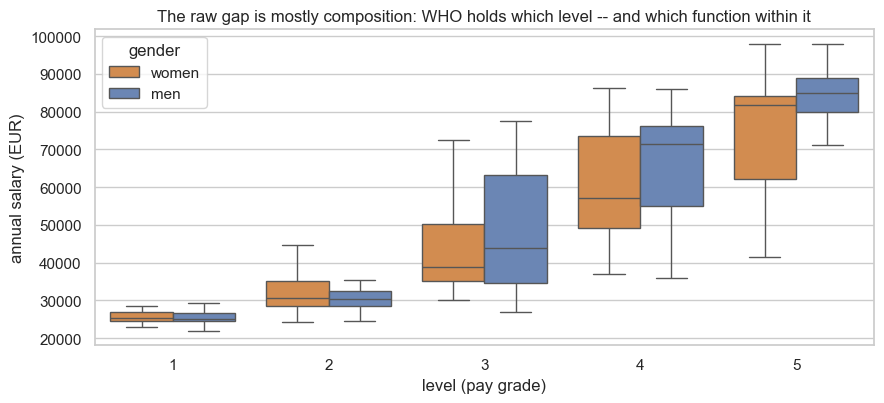

In [15]:
pay = active.copy()
pay["gender"] = np.where(pay.female == 1, "women", "men")

m_mean = pay.loc[pay.gender == "men", "salary"].mean()
w_mean = pay.loc[pay.gender == "women", "salary"].mean()
m_med = pay.loc[pay.gender == "men", "salary"].median()
w_med = pay.loc[pay.gender == "women", "salary"].median()
print(f"raw gap (means)  : women earn {1 - w_mean / m_mean:.1%} less "
      f"(EUR {w_mean:,.0f} vs EUR {m_mean:,.0f})")
print(f"raw gap (medians): {1 - w_med / m_med:.1%}")

comp = pd.concat({
    "headcount": pay.pivot_table(index="level", columns="gender", values="salary", aggfunc="size"),
    "mean salary": pay.pivot_table(index="level", columns="gender", values="salary",
                                   aggfunc="mean").round(-2),
}, axis=1)
print("\nlevel x gender -- the composition the raw gap mixes in:")
print(comp.to_string())

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.boxplot(data=pay, x="level", y="salary", hue="gender",
            palette={"men": "#5f83c0", "women": "#e88b3a"}, showfliers=False, ax=ax)
ax.set_xlabel("level (pay grade)")
ax.set_ylabel("annual salary (EUR)")
ax.set_title("The raw gap is mostly composition: WHO holds which level -- and which function within it")
plt.tight_layout()

In [16]:
pay["log_salary"] = np.log(pay.salary)
ols = smf.ols("log_salary ~ C(function) + level + tenure_m + perf + female",
              data=pay).fit(cov_type="HC1")
coef = ols.params["female"]
lo, hi = ols.conf_int().loc["female"]
print(f"adjusted (within-job) gap: {coef * 100:+.2f}% of salary   95% CI [{lo * 100:.2f}%, {hi * 100:.2f}%]")
print("(the generator planted   : -2.50% within level x function)")

raw_log = pay.loc[pay.female == 0, "log_salary"].mean() - pay.loc[pay.female == 1, "log_salary"].mean()
within_gap = -coef
print(f"\nOaxaca-style split of the raw log gap ({raw_log * 100:.1f}%):")
print(f"  composition -- function/level/tenure/perf mix : {(raw_log - within_gap) * 100:.1f} pp")
print(f"  within-job residual                           : {within_gap * 100:.1f} pp")

close_cost = (pay.loc[pay.female == 1, "salary"] * within_gap).sum()
print(f"\nclosing the within-job gap: ~EUR {close_cost:,.0f} per year, "
      f"across {int(pay.female.sum())} women")

adjusted (within-job) gap: -2.39% of salary   95% CI [-2.95%, -1.83%]


(the generator planted   : -2.50% within level x function)

Oaxaca-style split of the raw log gap (12.3%):
  composition -- function/level/tenure/perf mix : 9.9 pp
  within-job residual                           : 2.4 pp

closing the within-job gap: ~EUR 528,413 per year, across 524 women


The two numbers the works council actually needs, with their meanings attached:

1. **Raw gap: 13.1 % (means), 12.4 % (medians).** True, legally reportable, and *not* a payroll problem: the level × gender table shows women are roughly half of levels 1–2 but **5 of the 37 people at level 5**, and concentrated in support rather than engineering. This number is answered by **hiring, promotion and function mix** — structural levers, multi-year horizons. (Even the visible within-level gaps in the boxplot at levels 3–4 are mostly this: at the same level, women sit more often in support and men in engineering, which is why the regression below controls for function as well as level.)
2. **Within-job gap: −2.39 %, 95 % CI [−2.95, −1.83].** The regression recovers the planted −2.50 % almost exactly (a sliver is shaved off by survivorship — the most underpaid women have already left, which is its own grim data point). Small percentage, real money: **~€528k a year** across 524 women would close it — that *is* a salary-round line item, and the CI turns it into a range rather than a false-precision point.

Now the critical honesty note, and it is A4's language on purpose: **the controls in that regression are not confounders — several are mediators.** We *know* (we planted it) that level assignment itself tilts against women. Controlling for level therefore doesn't "remove a distortion"; it **absorbs part of the discrimination into the baseline** and reports only what's left. The −2.4 % is a *floor* on unfairness, not an estimate of it. This is the pay-equity version of A3's proxy discrimination and A4 §6's "who decided who got treated?": adjusting for a variable is only innocent if that variable was *fairly assigned*, and "adjusted gap ≈ 0, case closed" is how biased promotion pipelines buy themselves a clean audit. Report **both** numbers; let neither impersonate the other.

---

### ✋ Quick exercise (~2 min) — which number answers which question?

Four claims land in the salary-round meeting. For each, say whether the **raw** (13.1 %) or **within-job** (2.4 %) number is the right response, and what it costs to act on:

1. *"We should raise every woman's salary 13 % to close the gap."*
2. *"Adjusted for role, the gap is only 2.4 % — so there is no real problem."*
3. *"What would equal pay for equal work cost us next year?"*
4. *"Why is our reportable gap so much worse than our adjusted one?"*

In [17]:
# ✍️ Your turn 👇  (reasoning first -- then check claim 3 with one line)
# claim_3_cost = (women's salaries * within_gap).sum()  ... already printed above
# 1.
# 2.
# 3.
# 4.

<details>
<summary>✅ <b>Solution</b></summary>

```python
print("1. WRONG number  - 13.1% is mostly composition; a flat raise overshoots pay equity")
print("   and fixes nothing about who gets promoted.")
print("2. WRONG comfort - 2.4% is a FLOOR: level is a mediator, and we adjusted for it.")
print("3. WITHIN-JOB    - EUR", f"{(pay.loc[pay.female == 1, 'salary'] * within_gap).sum():,.0f}",
      "per year (plus the CI band around it).")
print("4. BOTH          - the distance from 13.1% raw to 2.4% within-job IS the finding:")
print("   it names promotion and function mix as the mechanism, which money alone cannot fix.")
```

The pattern to keep: **raw** answers reporting and structural questions, **within-job** answers payroll questions, and the *difference between them* is itself a diagnostic — it locates the problem in the pipeline rather than the paycheck. Any deck that shows only one of the two numbers has decided your conclusion for you.
</details>

## 6. What real people-analytics teams add (honest section)

Everything above is the load-bearing 80 %. What the production version layers on top — and where this notebook deliberately simplified:

- **Real survival tooling.** Our by-hand Kaplan–Meier is the concept; production uses **Cox proportional-hazards** models (covariates on the hazard, not separate curves per slice), **time-varying covariates** (engagement *changes*; we froze it), and **competing risks** — a resignation, a termination and an internal transfer are three different events that our single `left` flag mushes together. Libraries: `lifelines`, `scikit-survival`.
- **Sample sizes and k-anonymity.** 1,400 people is a *small-data* regime, and it gets smaller fast: any dashboard cell below ~10 heads is a de-anonymization device, not a statistic (Stretch C ends at a cell of five). Real teams enforce minimum cell sizes and suppress or pool everything below them — a privacy rule and a statistics rule that happen to be the same rule.
- **GDPR, the works council, and the AI Act.** Employee data is the most regulated data most companies hold. **GDPR Art. 22** limits fully automated decisions; in Germany the works council co-determines monitoring tech (**BetrVG §87**); and the **EU AI Act** (NB 52) classifies employment-related scoring as **high-risk**, with documentation, human-oversight and DPIA obligations. People analytics is a governance discipline that happens to contain a model.
- **Survey honesty is endogenous.** Engagement scores predict attrition — until employees learn the scores feed an attrition model, at which point they stop answering honestly and the feature dies (Goodhart's law, NB 18's metric-gaming warning, applied to your own colleagues). Real teams firewall survey analytics from individual-level action, *visibly*, because the firewall is what keeps the data worth having.
- **Self-fulfilling predictions.** A manager who sees a red flag invests less in that person; the person leaves; the model was "right". Attrition scores *change the system they predict* — NB 24's feedback loop with a human inside it. The mitigations are A4's: holdouts, and monitoring interventions rather than prophecies.
- **"Ask the managers" is a strong baseline this notebook never beat.** A good manager with a span of eight knows who is interviewing elsewhere before any model does. The model earns its keep where spans are wide, churn is fast, and attention is scarce — warehouse, in our story — which is *exactly* where the package economics failed. Real people-analytics teams therefore spend most of their effort on **aggregate diagnosis** (pay bands, workload, promotion pipelines, §5-style decompositions) and treat individual scoring as the last resort, not the product.
- **Pay-transparency law is arriving on a schedule.** EU Directive 2023/970 phases in gender-pay-gap reporting from 2027 and triggers a **joint pay assessment** when the unexplained gap exceeds 5 % — §5's raw-vs-adjusted machinery is about to stop being optional analytics and start being a compliance artifact.

## 🧠 The story in one screen

| # | The move | The number that carries it |
|---|---|---|
| 2 | Naive snapshot: leavers' mean tenure | "13.1 months" — vs stayers' 36.3 |
| 2 | Kaplan–Meier by hand: risk sets + censoring | honest median **41 months**; S(12) = 0.658 |
| 2 | Survival by function | Warehouse median **13 m** vs Engineering **90 m** |
| 3 | Expected leavers × role replacement cost | 153 expected (152 left last year); bill **€3.82 m/yr** |
| 3 | The rank flip: rate vs euros | WH 16.6 % / €1.01 m vs Eng 7.8 % / **€1.54 m** |
| 4 | Time-aware cohorts, temporal split | logistic **0.744** > boosting 0.727 > first-year rule 0.599 |
| 4 | Calibration, because euros read the level | top quintile predicted 0.324 / actual 0.307 |
| 4 | Break-even risk $p^* = C/(sR)$ | Eng **0.23**, Sales 0.36, Support 0.69, WH **0.79** |
| 4 | The race at a €60k budget | model **+€9.8k** vs first-year rule **−€38.5k** (god mode) |
| 5 | Raw vs within-job pay gap | **13.1 %** raw; **2.39 %** [1.83, 2.95] within-job |
| 5 | The split, and the mediator trap | 9.9 pp composition + 2.4 pp within-job (log scale); ~**€528k/yr** to close |
| 🧪 | The leak that predicts the past | last-survey feature: **0.968** AUC of fiction |

## 🧪 Practice exercises

### Exercise 1 — ⭐ Where the exit door is

The event table's `hazard` column is the risk of leaving *this month*, given survival so far. Plot it for the first 48 months (with a 3-month centered rolling mean — single months are noisy), and read off $h(1)$, $h(12)$ and $h(24)$. Where should Nordwerk's retention attention physically stand?

In [18]:
# Starter
# event.hazard has the monthly hazard; plot months 1..48 plus a rolling mean
# haz = event.hazard; smooth = haz.rolling(3, center=True).mean()

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
haz = event.hazard
smooth = haz.rolling(3, center=True).mean()
plt.figure(figsize=(8, 4))
plt.plot(event.month[:48], haz[:48] * 100, color="#b3b3b3", lw=1, label="monthly hazard")
plt.plot(event.month[:48], smooth[:48] * 100, color="#2e9c7c", lw=2, label="3-month rolling mean")
plt.xlabel("tenure (months)"); plt.ylabel("P(leave this month | still here), %")
plt.title("The exit door is at the entrance"); plt.legend(); plt.tight_layout()
print(f"h(1) = {haz[0]:.1%}   h(12) = {haz[11]:.1%}   h(24) = {haz[23]:.1%}")
```

$h(1)$ = **8.0 %** — a new hire's first month is ~13× as dangerous as a month in year two ($h(24)$ = 0.6 %), with $h(12)$ = 1.7 % in between. The curve *is* a staffing decision: onboarding, buddy programs and 90-day check-ins sit exactly under the spike, while anniversary-based gestures land where the hazard has already collapsed on its own. Stretch D turns this shape into euros.
</details>

### Exercise 2 — ⭐⭐ Overtime — a survival curve with a confounder inside

Split the workforce at 12 h/month of overtime and compare KM median tenures. The gap will look apocalyptic. Then compute the share of each *function* working ≥ 12 h overtime, redo the comparison **within Warehouse only**, and write one honest sentence about what the first comparison actually measured.

In [19]:
# Starter
# km_median(km_curve(df[df.overtime >= 12])) vs < 12; then per-function OT shares;
# then the same split inside df[df.function == "Warehouse"]

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def med_str(sub):
    m = km_median(km_curve(sub))
    return ">96" if np.isnan(m) else f"{int(m)}"

hi_ot, lo_ot = df[df.overtime >= 12], df[df.overtime < 12]
print(f"OT >= 12 h/m: n = {len(hi_ot):,}, KM median {med_str(hi_ot)} months")
print(f"OT <  12 h/m: n = {len(lo_ot):,}, KM median {med_str(lo_ot)} months")
print("\nshare working >= 12 h overtime, by function:")
print(df.groupby("function").overtime.apply(lambda s: (s >= 12).mean()).round(2).to_string())
wh = df[df.function == "Warehouse"]
print(f"\nWarehouse only -- OT >= 12: median {med_str(wh[wh.overtime >= 12])} m"
      f"; OT < 12: median {med_str(wh[wh.overtime < 12])} m")
```

Medians of **7 vs 71 months** — a tenfold gap that would headline any board deck. But 43 % of warehouse works heavy overtime against 14 % of engineering, so the raw split partly re-measures *function* (base hazards differ by more than 2×). Within Warehouse the gap is **5 vs 41 months** — still enormous, because in this simulation overtime genuinely drives exits (directly, and again through the engagement it erodes). The honest sentence: *"heavy overtime is associated with drastically shorter tenure even within function; how much of that survives a real confounder audit — who gets assigned overtime, and why — is an A4 §6 question, not a survival-curve question."* Descriptive curves locate the fire; they don't name the arsonist.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the attrition model that predicted the past

A colleague "improves" §4's model with one extra column and reports a breakthrough. Their pipeline is below and runs without error — reproduce it, explain the number, and say what the model will do the day it scores *current* employees.

In [20]:
# Their pipeline -- it runs, and that's the problem
X_tr_leak = X_tr.assign(last_survey=train.last_survey.values)
X_va_leak = X_va.assign(last_survey=valid.last_survey.values)
gbm_leak = HistGradientBoostingClassifier(random_state=0, max_leaf_nodes=7,
                                          learning_rate=0.06, min_samples_leaf=40).fit(X_tr_leak, train.y)
auc_leak = roc_auc_score(valid.y, gbm_leak.predict_proba(X_va_leak)[:, 1])
print(f"AUC with the 'engagement upgrade': {auc_leak:.3f}   ->   promote this to production??")

AUC with the 'engagement upgrade': 0.968   ->   promote this to production??


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
print(f"colleague's AUC: {auc_leak:.3f}   honest logistic from SS4: {roc_auc_score(valid.y, p_lr):.3f}")
print("\nmean last_survey by outcome (validation cohort):")
print(valid.groupby("y").last_survey.mean().round(2).to_string())
```

`last_survey` is the most recent survey wave **on file at the end of the data** — and for a leaver, the last wave they ever answered is the bitter one filed weeks before the resignation (leavers average ~**2.1** vs stayers' ~**3.6**). The feature is dated *after* the label window opens: the model isn't predicting the future, it's **reading the exit interview**. Hence 0.968 — and hence uselessness: score today's workforce and everyone's most recent wave is just an ordinary wave, so the magic evaporates exactly when money is on the line. The fix is mechanical: every feature must carry a timestamp, and a cohort built *as of* month $c$ may only consume values stamped $\le c$ — which is what §4's `engagement` (the wave in force at the snapshot) already was. Same disease as NB 23's 0.99-AUC trap and NB 26's unshifted rolling windows; HR's variant just hides better, because "our newest survey" *sounds* like a feature, not a leak.
</details>

### Exercise 4 — ⭐⭐ The CFO's pessimistic scenario

The CFO doesn't believe the 25 % save rate ("consultants made it up") and wants the program priced at **15 % save rate and €4,000 true package cost** (admin included). Recompute the break-even thresholds and rebuild §4's list under those assumptions. What survives — and what is the honest deliverable when the answer flips inside a plausible assumption range?

In [21]:
# Starter
# for (s_, c_) in [(0.25, 3000.0), (0.15, 4000.0)]:
#     ev_ = p_hat * s_ * repl_va - c_        # per-employee expected value
#     ... count ev_ > 0, sum the god-mode expected value of that list

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
for label, s_, c_ in [("assumed (SS4)      ", 0.25, 3_000.0),
                      ("CFO's pessimistic  ", 0.15, 4_000.0)]:
    ev_ = p_hat * s_ * repl_va - c_
    sel = ev_ > 0
    god_ = (valid.p12_true.values[sel] * s_ * repl_va[sel] - c_).sum()
    be_eng = c_ / (s_ * cost_table.avg_repl_eur["Engineering"])
    print(f"{label}: p*(Engineering) = {be_eng:.2f} -> {int(sel.sum()):2d} employees clear it"
          f"; expected value EUR {god_:,.0f}")
```

Under the CFO's numbers the engineering break-even jumps from 0.23 to **~0.50** — above the model's top validated score — and the positive-EV list is **empty**: the program doesn't shrink, it *vanishes*. A decision that reverses inside the plausible range of an **assumed** parameter is not a decision yet; it's a measurement request. The honest deliverable is A2's: a randomized pilot that *measures* the save rate (Stretch B prices it — and finds a harder truth), with the program's go/no-go pinned to the estimate. What you must *not* do is average the two scenarios and ship half a program: the value of information here is the entire budget.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Error bars on a median

§2's headline — median tenure 41 months — is a point estimate from one realization of history. Bootstrap it: resample the 2,550 rows with replacement 300 times, recompute the KM median each time, and report a 95 % interval. (Map "curve never reaches 0.5" to 97 so the percentile has something to chew on.) Then say in one sentence why the works council should hear the interval and not the point.

In [22]:
# Starter -- sketch:
# rng_bs = np.random.default_rng(0)
# for _ in range(300):
#     bs = df.sample(len(df), replace=True, random_state=rng_bs.integers(1e9))
#     medians.append(km_median(km_curve(bs)))   # nan -> 97

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rng_bs = np.random.default_rng(0)
medians = []
for _ in range(300):
    bs = df.sample(len(df), replace=True, random_state=rng_bs.integers(1e9))
    m = km_median(km_curve(bs))
    medians.append(97 if np.isnan(m) else m)
lo_b, hi_b = np.percentile(medians, [2.5, 97.5])
print(f"KM median tenure: {km_median(event)} months; bootstrap 95% CI [{lo_b:.0f}, {hi_b:.0f}]")
```

The interval lands around **[36, 47] months** — a ±5-month handle on a 41-month headline, from a full company's worth of data. Slice it (per function, per site, per manager) and the intervals widen past usefulness quickly; that is the small-$n$ regime doing what it always does. The sentence for the works council: *"median tenure is about three and a half years, and anything we tell you at finer grain than ±5 months is decoration."* NB 10's rule — no estimate leaves the building without its wobble — binds hardest exactly where audiences most want a single number.
</details>

### Stretch exercise B — ⭐⭐⭐ The pilot before the program — and the sleeping dogs of HR

§4's economics stand on an *assumed* 25 % save rate. Price the measurement: (1) compute the **break-even save rate** $s^* = C/(\bar p \cdot R)$ for the targeted engineering pool (use $\bar p = 0.30$, their observed leave rate); (2) compute the MDE of a randomized pilot with 100 employees per arm (A2's $2.8\sqrt{2 p(1-p)/n}$ shorthand) and compare it with the effect a 25 % save rate would actually produce; (3) compute the $n$ per arm you'd need for 80 % power. Then explain why the control group is non-negotiable — citing what A4 called sleeping dogs.

In [23]:
# Starter -- sketch:
# s_star = PKG_COST / (0.30 * cost_table.avg_repl_eur["Engineering"])
# effect = SAVE_RATE * 0.30            # 25% of a 0.30 leave rate = 7.5 pp
# mde = 2.8 * sqrt(2 * .3 * .7 / 100); n_needed = 2*p*(1-p)*(2.8/effect)**2

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
p_pool = 0.30
s_star = PKG_COST / (p_pool * cost_table.avg_repl_eur["Engineering"])
effect = SAVE_RATE * p_pool
mde = 2.8 * np.sqrt(2 * p_pool * (1 - p_pool) / 100)
n_needed = 2 * p_pool * (1 - p_pool) * (2.8 / effect) ** 2
print(f"break-even save rate (Engineering pool): {s_star:.1%}")
print(f"pilot, 100/arm: MDE = {mde * 100:.1f} pp vs hoped-for effect {effect * 100:.1f} pp")
print(f"n per arm for 80% power: ~{n_needed:.0f}")
```

Three uncomfortable numbers. The program only makes money if the true save rate beats **~19 %** — uncomfortably close to the assumed 25 %. A 100-per-arm pilot resolves **18 pp** while the effect to detect is **7.5 pp** — the instrument can't read the dial (A2's cancelled checkout test, in HR clothing). And 80 % power needs **~585 per arm** — Nordwerk doesn't *have* 585 at-risk engineers; it has a few dozen a year. The honest designs are slow ones: a permanent randomized holdout pooled over several years, or a multi-site rollout stepped like A4 §5's DiD. And the control group is not statistical hygiene — it's how you detect HR's **sleeping dogs**: a "we value you, please stay" conversation tells some employees, accurately, that they have leverage and options — and *starts* the job search it meant to prevent. Without a control arm, that backfire is invisible; you'll just see treated people leaving more and misread it as targeting (A4 §1, beat for beat).
</details>

### Stretch exercise C — ⭐⭐⭐ The pay gap at n = 38 (and at n = 5)

§5's regression pools the whole company. The works council asks about one cell: **Engineering, levels 4–5**. Compute the observed mean salary gap there, then test it with a **permutation test** (shuffle the gender labels within the cell 5,000 times, seed 3; one-sided p). Then count level-5 women company-wide and explain what number you may *not* publish, and why the statistics and the privacy rule agree.

In [24]:
# Starter -- sketch:
# cell = pay[(pay.function == "Engineering") & (pay.level >= 4)]
# gap_obs = men's mean - women's mean
# 5000x: permute cell.female, recompute the gap, p = share(perm >= gap_obs)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
cell = pay[(pay.function == "Engineering") & (pay.level >= 4)]
gap_obs = cell.loc[cell.female == 0, "salary"].mean() - cell.loc[cell.female == 1, "salary"].mean()
rng_p = np.random.default_rng(3)
fvals = cell.female.values
perm = []
for _ in range(5000):
    p_ = rng_p.permutation(fvals)
    perm.append(cell.salary.values[p_ == 0].mean() - cell.salary.values[p_ == 1].mean())
p_val = (np.array(perm) >= gap_obs).mean()
print(f"Engineering L4-5: {int(cell.female.sum())} women vs {int((cell.female == 0).sum())} men")
print(f"observed gap EUR {gap_obs:,.0f}; one-sided permutation p = {p_val:.3f}")
n5w = int(((pay.level == 5) & (pay.female == 1)).sum())
n5m = int(((pay.level == 5) & (pay.female == 0)).sum())
print(f"level-5 women in the whole company: {n5w} (men: {n5m})")
```

At 38 women vs 136 men, the ~**€2.4k** gap earns a permutation $p \approx 0.02$ — small cells are not hopeless *if* you use a test that makes no normality promises (the permutation test's only assumption is exchangeability under the null, which is exactly the question). But at **five** level-5 women, no test rescues you — and worse, *"mean salary of level-5 women"* is functionally a named individual's payslip with four witnesses. The k-anonymity rule (suppress cells below ~10) and the statistical rule (don't estimate from cells below ~10) are the same rule arriving from two directions; real dashboards enforce it before anyone asks.
</details>

### Stretch exercise D — ⭐⭐ Timing the intervention from the shape of the hazard

Exercise 1 found the hazard cliff at the start of tenure. Suppose a warehouse intervention (onboarding buddy + weekly check-ins) cuts the monthly hazard by 25 % for six months, and can be scheduled to start in month 1, 7, 13 or 25 of tenure. Using the estimated warehouse hazard `HZ["Warehouse"]`, compute exits prevented per 100 hires within 36 months for each start — and the euro value at the warehouse replacement cost. When should it run, and how does this rescue the function §4's package economics abandoned?

In [25]:
# Starter -- sketch:
# h_ = HZ["Warehouse"][:36].copy(); h_[start:start+6] *= 0.75
# exits/100 = (1 - prod(1 - h_)) * 100; compare starts 0, 6, 12, 24

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
hz_wh = HZ["Warehouse"]

def exits_per_100(start=None):
    h_ = hz_wh[:36].copy()
    if start is not None:
        h_[start:start + 6] = h_[start:start + 6] * (1 - SAVE_RATE)
    return (1 - np.prod(1 - h_)) * 100

base = exits_per_100()
print(f"baseline: {base:.1f} of 100 warehouse hires gone within 36 months")
for s_ in (0, 6, 12, 24):
    saved = base - exits_per_100(s_)
    print(f"  program in tenure months {s_ + 1:>2}-{s_ + 6:>2}: {saved:.2f} exits prevented"
          f" per 100 hires -> EUR {saved * cost_table.avg_repl_eur['Warehouse']:,.0f}")
```

Same program, four calendars: starting in **month 1** prevents ~**4.7** exits per 100 hires (~**€71k** of replacement cost), starting in month 25 prevents ~0.8 — a **6×** difference bought purely by standing where the hazard is. And notice what just happened to §4's "warehouse is untreatable" verdict: it was true *for a €3,000 per-head package aimed at individuals*. A hazard-shaped **cohort** intervention at, say, €300 per hire costs €30k per 100 hires against €71k recovered — comfortably positive, no model required, no individual ever scored. The hazard curve, not the risk ranking, was the decision variable; when someone says "the model says we can't help warehouse", the correct reply is "the *package* can't — change the instrument, and time it."
</details>

## 🎁 Bonus mini-project — the CHRO one-pager

Write the single page the CHRO takes into the executive committee. It must answer four questions with numbers from this notebook — and every number must carry one of three source tags: **measured** (computed from the extract), **modeled** (out-of-sample validated), or **assumed** (someone chose it). If a sentence can't name its tag, it doesn't ship.

1. **What does attrition cost, and where?** The €3.82 m bill, the rate-vs-euros rank flip, and which function's line item funds the program. *(measured)*
2. **What do we do about it?** The two-instrument answer: economics-ranked packages for engineering/sales (20 names, +€9.8k expected vs −€38.5k for the first-year heuristic), and a hazard-timed onboarding program for warehouse (Stretch D). State the break-even logic in one sentence each. *(modeled — except the save rate, which is **assumed**, and the memo must say so in bold)*
3. **The pay-gap answer for the works council.** Both numbers with their meanings, the €528k/yr cost of closing the within-job gap, the CI, and one sentence on why the adjusted number is a floor (the mediator caveat) — written so a non-statistician cannot misquote it. *(measured, with stated model)*
4. **The standing request.** The randomized pilot that turns the assumed save rate into a measured one (Stretch B's sample-size reality included), plus the governance boundaries: minimum cell sizes, no automated adverse decisions, scores feed conversations only.

Grading yourself: could an executive make the *wrong* decision from your page by quoting it accurately? If yes, rewrite the sentence they'd quote.

## ✅ Self-assessment checklist

- [ ] I can explain censoring with the race-photograph analogy and name the three artifacts it plants in leaver/stayer snapshots (fake rate, tenure artifact, exposure gradient).
- [ ] I can build a Kaplan–Meier curve by hand — risk sets, event table, $h(t)$, $S(t)$ — and read medians off it, including "median > window" honestly.
- [ ] I can turn a hazard curve into expected leavers and euros, and explain why the highest-*rate* function is not the highest-*cost* one.
- [ ] I can construct a time-aware cohort with a fully observed 12-month label, split it temporally, and beat the first-year heuristic in euros — not AUC.
- [ ] I can derive $p^* = C/(s \cdot R)$, produce a budget-constrained ranked list, and explain why "at-risk" and "treatable" are different lists.
- [ ] I can report a pay gap as two numbers, decompose raw = composition + within-job, and state the mediator caveat that makes the adjusted number a floor.
- [ ] I can name the governance stack — k-anonymity, GDPR Art. 22, works-council codetermination, survey honesty, self-fulfilling scores — and say where the model must *not* be used.

## 🚀 Where next

- **NB 23** is the economic chassis this notebook re-bodied for HR — reread its break-even section and notice the formula never changed, only the nouns.
- **A4** for what the retention program still lacks: the save rate is a *causal effect*, and measuring it per-segment is uplift modeling with employees in the rows (mind the sleeping dogs).
- **A2** before running Stretch B's pilot for real: MDE first, CUPED with last year's engagement as the covariate, and no peeking at the quarterly HR review.
- **A3's Stretch C** for the disparate-impact audit that any shipped intervention list owes its subjects.
- Real-world tooling when the by-hand versions have taught what they teach: `lifelines` / `scikit-survival` (Cox, competing risks), and the EU Pay Transparency Directive (2023/970) plus Germany's EntgTranspG for what §5 becomes as law.

---

> 🧭  [◀ A4 — Causal Inference & Uplift](./A4_causal_uplift.ipynb)  ·  [Module 7 index](./README.md)  ·  [A6 — Finance: AR & Cash Flow ▶](./A6_finance_ar_cashflow.ipynb)  ·  [🏠 Course home](../README.md)